In [1]:
# this section works!!!!
# USE this part !!!!

import yt
import numpy as np
import pandas as pd

d1 = "/Users/potato/Downloads/plt59250"
#d1 = '/home/u0890475/Downloads/plt59250'
ds = yt.load(d1)

ds.force_periodicity()
ds.add_gradient_fields(("boxlib", "Y(H2)"))

Tkey = ("boxlib", "temp")
mass_fields = [f for f in ds.field_list if "Y(" in f[1]]

# fields we will load per grid
grad_keys = [
    ("boxlib", "Y(H2)_gradient_x"),
    ("boxlib", "Y(H2)_gradient_y"),
    ("boxlib", "Y(H2)_gradient_z"),
]

# Collect chunks here
chunks = []

# Loop over AMR grid patches (memory-safe)
for g in ds.index.grids:
    # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    if float(g.LeftEdge[0]) >= 0.07:
        continue

    # Pull minimal fields first (to build mask cheaply)
    x = g[("index", "x")].ndarray_view().ravel()
    T = g[Tkey].ndarray_view().ravel()

    mask = (T > 330.0) & (x < 0.07)
    if not np.any(mask):
        continue

    # Now pull only what you need (still per-grid, so small)
    y  = g[("index", "y")].ndarray_view().ravel()
    z  = g[("index", "z")].ndarray_view().ravel()
    dx = g[("index", "dx")].ndarray_view().ravel()

    gh2x = g[grad_keys[0]].ndarray_view().ravel()
    gh2y = g[grad_keys[1]].ndarray_view().ravel()
    gh2z = g[grad_keys[2]].ndarray_view().ravel()
    gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

    data = {
        "x": x[mask],
        "y": y[mask],
        "z": z[mask],
        "T": T[mask],
        "gridsize": dx[mask],
        "gh2x": gh2x[mask],
        "gh2y": gh2y[mask],
        "gh2z": gh2z[mask],
        "gh2mag": gh2mag[mask],
    }

    # mass fractions (only masked cells)
    for f in mass_fields:
        data[f[1]] = g[f].ndarray_view().ravel()[mask]

    chunks.append(pd.DataFrame(data))

# Final dataframe
if len(chunks) == 0:
    raise RuntimeError("No cells found for (T>350) & (x<0.07).")

df_350 = pd.concat(chunks, ignore_index=True)
print("df_350 shape:", df_350.shape)
print(df_350.head())


yt : [INFO     ] 2026-02-23 14:35:15,646 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-02-23 14:35:15,646 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-02-23 14:35:15,647 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-02-23 14:35:15,647 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


df_350 shape: (160767, 18)
          x         y         z           T  gridsize       gh2x      gh2y  \
0  0.069863  0.000137  0.000137  683.491606  0.000273 -16.079777  2.367719   
1  0.069863  0.000137  0.000410  538.985508  0.000273 -14.652656  5.718231   
2  0.069863  0.000410  0.000137  646.228079  0.000273 -16.725949  3.262778   
3  0.069863  0.000410  0.000410  413.311823  0.000273 -11.726164  5.189171   
4  0.069863  0.000684  0.000137  607.609543  0.000273 -17.017937  2.965425   

        gh2z     gh2mag      Y(H)     Y(H2)    Y(H2O)   Y(H2O2)    Y(HO2)  \
0  -8.109910  18.164140  0.000022  0.005784  0.062257  0.000138  0.000237   
1  10.437974  18.877230  0.000007  0.008605  0.022043  0.000069  0.000188   
2  -4.865877  17.722298  0.000021  0.006683  0.055925  0.000137  0.000233   
3  10.953670  16.864557  0.000002  0.010379  0.009675  0.000038  0.000109   
4  -2.920740  17.519551  0.000019  0.007568  0.048256  0.000131  0.000224   

      Y(N2)      Y(O)     Y(O2)     Y(OH)

In [4]:
"""
import yt
import numpy as np
import pandas as pd

#d1 = "/Users/potato/Downloads/plt59250"
d1 = '/home/u0890475/Downloads/plt59250'
ds = yt.load(d1)

ds.force_periodicity()
ad = ds.all_data()
x = ad[("index","x")].ndarray_view()
y = ad[("index","y")].ndarray_view()
z = ad[("index","z")].ndarray_view()

x_unique = np.unique(x)
y_unique = np.unique(y)
z_unique = np.unique(z)

print("Nx =", len(x_unique))
print("Ny =", len(y_unique))
print("Nz =", len(z_unique))
"""
df_out = df_350.copy()
x_cold_region = df_out['x'].min()-0.003
x_cold_region

0.06269335937499998

In [5]:
for g in ds.index.grids:
    # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    if float(g.LeftEdge[0]) >= 0.07:
        continue

    # Pull minimal fields first (to build mask cheaply)
    x = g[("index", "x")].ndarray_view().ravel()
    T = g[Tkey].ndarray_view().ravel()

    mask = (x>=x_cold_region) & (x < 0.07)
    if not np.any(mask):
        continue

    # Now pull only what you need (still per-grid, so small)
    y  = g[("index", "y")].ndarray_view().ravel()
    z  = g[("index", "z")].ndarray_view().ravel()
    dx = g[("index", "dx")].ndarray_view().ravel()

    gh2x = g[grad_keys[0]].ndarray_view().ravel()
    gh2y = g[grad_keys[1]].ndarray_view().ravel()
    gh2z = g[grad_keys[2]].ndarray_view().ravel()
    gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

    data = {
        "x": x[mask],
        "y": y[mask],
        "z": z[mask],
        "T": T[mask],
        "gridsize": dx[mask],
        "gh2x": gh2x[mask],
        "gh2y": gh2y[mask],
        "gh2z": gh2z[mask],
        "gh2mag": gh2mag[mask],
    }

    # mass fractions (only masked cells)
    for f in mass_fields:
        data[f[1]] = g[f].ndarray_view().ravel()[mask]

    chunks.append(pd.DataFrame(data))

# Final dataframe
if len(chunks) == 0:
    raise RuntimeError("No cells found for (T>350) & (x<0.07).")

df_350 = pd.concat(chunks, ignore_index=True)
print("df_350 shape:", df_350.shape)
print(df_350.head())


df_350 shape: (1990079, 18)
          x         y         z           T  gridsize       gh2x      gh2y  \
0  0.069863  0.000137  0.000137  683.491606  0.000273 -16.079777  2.367719   
1  0.069863  0.000137  0.000410  538.985508  0.000273 -14.652656  5.718231   
2  0.069863  0.000410  0.000137  646.228079  0.000273 -16.725949  3.262778   
3  0.069863  0.000410  0.000410  413.311823  0.000273 -11.726164  5.189171   
4  0.069863  0.000684  0.000137  607.609543  0.000273 -17.017937  2.965425   

        gh2z     gh2mag      Y(H)     Y(H2)    Y(H2O)   Y(H2O2)    Y(HO2)  \
0  -8.109910  18.164140  0.000022  0.005784  0.062257  0.000138  0.000237   
1  10.437974  18.877230  0.000007  0.008605  0.022043  0.000069  0.000188   
2  -4.865877  17.722298  0.000021  0.006683  0.055925  0.000137  0.000233   
3  10.953670  16.864557  0.000002  0.010379  0.009675  0.000038  0.000109   
4  -2.920740  17.519551  0.000019  0.007568  0.048256  0.000131  0.000224   

      Y(N2)      Y(O)     Y(O2)     Y(OH

In [13]:
df_out['x'].min()

0.06270263671875

In [38]:
df_out = df_350.copy()
# trying to find the T>315k
T_cutoff = 310
min_idx = df_out[df_out['T']>T_cutoff]['x'].idxmin()
df_out.iloc[min_idx]

x           6.559082e-02
y           6.870117e-03
z           1.708984e-04
T           3.103718e+02
gridsize    6.835937e-05
gh2x       -3.982129e+00
gh2y       -4.125298e-01
gh2z        2.807554e-01
gh2mag      4.013272e+00
Y(H)        1.323534e-14
Y(H2)       1.239798e-02
Y(H2O)      9.385659e-03
Y(H2O2)     5.569660e-05
Y(HO2)      7.461542e-06
Y(N2)       7.568367e-01
Y(O)        1.958749e-10
Y(O2)       2.213165e-01
Y(OH)       5.077257e-11
Name: 632993, dtype: float64

In [31]:
pathline_dict = []

# pathline dictionary contains the seeking coordinate
pathline = []


df_x = sorted(list(set(df_out['x'].values)))
df_y = sorted(list(set(df_out['y'].values)))
df_z = sorted(list(set(df_out['z'].values)))


index_col = ['x', 'y', 'z']
header_col = [ec for ec in df_out.columns if 'Y('  in ec ]
header_col.append('T')
header_col.extend( ['gh2x','gh2y', 'gh2z'])
full_col = index_col+ header_col

In [32]:
import bisect
# pathline contains coordinate only

from scipy.spatial import cKDTree


# pathlinne dictionary of list: 
# each dictionary contains key: index from df, value: weighting factor

def find_pathline(df, x0,y0,z0,cutoff_value,max_length,curr_dx):
    find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx)
    
    return 




# find weighting factor of each points of the cubic
# the return dictionary:
# key: global index, value: weighting factor of that index
def get_weight_w_point(df,x0,y0,z0,curr_dx):

        
    temp_ls, _ = find_pts(df,x0,y0,z0,curr_dx)
    temp_dist = []
    subdf = df_out[['x', 'y', 'z']].loc[temp_ls]
    for i in range(subdf.shape[0]):
        temp_dist.append( 1/((subdf['x'].iloc[i] - x0)**2 +   (subdf['y'].iloc[i] - y0)**2 +(subdf['z'].iloc[i] - z0)**2) )

    sum_weight = sum(temp_dist)
    weight_dict = {}
    for i in range(subdf.shape[0]):
        weight_dict[subdf.index[i]] = temp_dist[i] /  sum_weight

    
    return weight_dict

def find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx):
    # if the line is long enough, then return
    if len(pathline)>=2:
        pt0 = pathline[0]
        ptlast = pathline[-1]
        distance = ((pt0[0] - ptlast[0])**2  + (pt0[1] - ptlast[1])**2 + (pt0[2] - ptlast[2])**2 )**0.5
        if distance >= cutoff_value:
            return 
    if len(pathline_dict) >= max_length:
            return 

    temp_weight_dict = get_weight_w_point(df,x0,y0,z0,curr_dx)

    # make sure the indexes of pathline and pathline dict are aligned
    pathline.append([x0,y0,z0])
    pathline_dict.append(temp_weight_dict)


    # that's the c_i/ |c| part 
    x_dirc, y_dirc, z_dirc = 0,0,0
    next_dx  =  0
    for k,v in temp_weight_dict.items():
        x_dirc += (df['gh2x'].iloc[k] * v)
        y_dirc += (df['gh2y'].iloc[k] * v)
        z_dirc += (df['gh2z'].iloc[k] * v)
        #next_dx = max(next_dx, df['gridsize'].iloc[k])
    next_dx = curr_dx
    norm_dist = (x_dirc**2+ y_dirc**2+z_dirc**2)**0.5
    x_next = x0  - x_dirc/norm_dist * next_dx
    y_next = y0  - y_dirc/norm_dist * next_dx
    z_next = z0  - z_dirc/norm_dist * next_dx
    print(f'The next point is x: {x_next}, y: {y_next} , z: {z_next}')

    find_next_point_cubic(df,x_next,y_next,z_next,cutoff_value,max_length,next_dx)
        
    return 





# supposed to return a directionary/list with 8 pts (index)
def find_pts(df,x0,y0,z0,curr_dx):
    pts_good = []
    coord_dict = {}
    
    
    xbl, xbr = x0 - 4*curr_dx, x0 + 4*curr_dx
    ybl, ybr = y0 - 4*curr_dx, y0 + 4*curr_dx
    zbl, zbr = z0 - 4*curr_dx, z0 + 4*curr_dx
    
    # the 01 indiation of cubic
    coord_idx = [[-1,-1,-1], [-1,-1,1], [-1,1,-1],[-1,1,1],
                [1,-1,-1], [1,-1,1], [1,1,-1],[1,1,1], ]


    for ec in coord_idx:
        x_edge = xbr if ec[0] ==1 else xbl
        y_edge = ybr if ec[1] ==1 else ybl
        z_edge = zbr if ec[2] ==1 else zbl

        subxl, subxr = min(x_edge,x0), max(x_edge,x0)
        subyl, subyr = min(y_edge,y0), max(y_edge,y0)
        subzl, subzr = min(z_edge,z0), max(z_edge,z0)
        #print(f'Find from x : {subxl} to {subxr}.')
        #print(f'Find from y : {subyl} to {subyr}.')
        #print(f'Find from z : {subzl} to {subzr}.')
        temp_cut = df[ (df['x'] > subxl) &  (df['x'] <= subxr) & (df['y'] > subyl) &  (df['y'] <= subyr) & (df['z'] > subzl) &  (df['z'] <= subzr)]
        df_cut = temp_cut.copy()
        points = df_cut[['x','y','z']].to_numpy()
        tree = cKDTree(points)

        query_point = np.array([x0, y0, z0])
        # index is the index of the original df
        # and this index need to be stored and used
        #dist, idx = tree.query(query_point)
        #print(f"for {ec} is nearest index is {idx} with distance {dist} x:{df_out['x'].loc[idx]}, y:{df_out['y'].loc[idx]}, z:{df_out['z'].loc[idx]}.")
        dist, i_local = tree.query(query_point)
        #print(i_local)
        row = df_cut.iloc[int(i_local)]          # row inside df_cut (guaranteed in-range)
        idx_global = df_cut.index[int(i_local)]  # original df index label
        """
        print(f"for {ec} nearest df index is {idx_global} with distance {dist} "
              f"x:{row['x']}, y:{row['y']}, z:{row['z']}.")
        """
        pts_good.append(idx_global)
        coord_dict[tuple(ec)] = idx_global
        


    return pts_good, coord_dict


        

    

    


In [33]:
def get_T_Mass_from_list(pathline,pathline_dict):

    #final_df = pd.DataFrame(columns=full_col)
    # this list combined 2 items, [index, value]
    # then sort by index. 
    final_list = []
    for i in range(len(pathline_dict)):
        temp_dict = pathline_dict[i]
        temp_target_coord = pathline[i]
        
        temp_intp_list = []
        temp_intp_list.extend(pathline[i])
        temp_intp_weight = []
        #print(temp_dict)
        w=pd.Series(temp_dict, name="weight")
        temo_subdf = df_out[header_col].loc[w.index].copy()
        temo_subdf["weight"] = w
        #num_cols = df_selected.select_dtypes(include="number").columns
        df_weighted = temo_subdf[header_col].multiply(temo_subdf["weight"], axis=0)
        
        for i in range(len(header_col)):
            #print(df_weighted[header_col[i]])
            temp_intp_list.append(sum(df_weighted[header_col[i]]))
        final_list.append(temp_intp_list)
    
        
    return pd.DataFrame(final_list,columns = full_col)
            
            

In [34]:
df_out.iloc[min_idx]

x           6.559082e-02
y           6.870117e-03
z           1.708984e-04
T           3.103718e+02
gridsize    6.835937e-05
gh2x       -3.982129e+00
gh2y       -4.125298e-01
gh2z        2.807554e-01
gh2mag      4.013272e+00
Y(H)        1.323534e-14
Y(H2)       1.239798e-02
Y(H2O)      9.385659e-03
Y(H2O2)     5.569660e-05
Y(HO2)      7.461542e-06
Y(N2)       7.568367e-01
Y(O)        1.958749e-10
Y(O2)       2.213165e-01
Y(OH)       5.077257e-11
Name: 632993, dtype: float64

In [35]:
#df_x[15]
#find_pathline(df_out, 6.581299e-02,6.887207e-03,2.221680e-04,0.0035,500,34.1e-6)
find_pathline(df_out, 6.559082e-02 ,6.870117e-03 ,1.708984e-04,0.004,500,34.1e-6)
#test1_ls,test1_dict = find_pts(df_out,  0.066292,0.007708,0.000085, )
#df_subset = df_out[['x','y','z']].loc[test1_ls]

#df_subset.index[0]
#find_pathline(df_out, 0.0035,500,)
#pathline
#p1,l1 = find_pts(df_out,0.066292,0.007708,0.000085,34.1e-6)
#df_out.iloc[p1]
result_df = get_T_Mass_from_list(pathline,pathline_dict)
result_df

The next point is x: 0.06562465538001745, y: 0.006873622186245396 , z: 0.0001685128752235003
The next point is x: 0.0656585201503767, y: 0.00687737360008002 , z: 0.00016712932083082823
The next point is x: 0.0656923591780204, y: 0.006881370443453482 , z: 0.00016580438642607546
The next point is x: 0.06572621266182177, y: 0.006885449628569252 , z: 0.00016546989681312508
The next point is x: 0.06576001645630371, y: 0.006889897613513928 , z: 0.0001648963913165324
The next point is x: 0.06579387651734521, y: 0.006893917772681711 , z: 0.0001645161459592166
The next point is x: 0.0658276900330323, y: 0.006898318707538222 , z: 0.00016421961726260814
The next point is x: 0.06586148105574528, y: 0.006902858341218655 , z: 0.0001636125669701139
The next point is x: 0.06589524686933325, y: 0.006907603628677521 , z: 0.00016320997576878455
The next point is x: 0.06592897367907953, y: 0.006912577194436181 , z: 0.00016245106340053312
The next point is x: 0.06596269103689453, y: 0.0069176397723177034 ,

,x,y,z,Y(H),Y(H2),Y(H2O),Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH),T,gh2x,gh2y,gh2z
0,0.065591,0.006870,0.000171,1.323534e-14,0.012398,0.009386,0.000056,0.000007,0.756837,1.958749e-10,0.221317,5.077257e-11,310.371793,-3.982129,-0.412530,0.280755
1,0.065625,0.006874,0.000169,1.245698e-14,0.012250,0.010272,0.000063,0.000011,0.756778,2.916348e-10,0.220626,9.270298e-11,315.365119,-4.727736,-0.523721,0.193153
2,0.065659,0.006877,0.000167,-2.421332e-14,0.012077,0.011273,0.000072,0.000015,0.756699,4.423535e-10,0.219863,1.732776e-10,322.098555,-5.621239,-0.663944,0.220094
3,0.065692,0.006881,0.000166,-2.524428e-13,0.011863,0.012467,0.000082,0.000022,0.756602,7.334232e-10,0.218965,3.829390e-10,331.043075,-6.618224,-0.797465,0.065391
4,0.065726,0.006885,0.000165,-8.353101e-13,0.011629,0.013878,0.000094,0.000031,0.756473,1.249458e-09,0.217895,8.677744e-10,342.647997,-7.652319,-1.006911,0.129827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.069433,0.007437,0.000245,7.125322e-06,0.000083,0.144618,0.000010,0.000032,0.756612,1.837663e-04,0.097922,5.315972e-04,1165.006050,-0.020695,-0.001131,-0.002245
116,0.069467,0.007439,0.000249,7.050123e-06,0.000082,0.144443,0.000010,0.000032,0.756604,1.832472e-04,0.098107,5.318265e-04,1167.126732,-0.020264,-0.001241,-0.002034
117,0.069501,0.007441,0.000252,6.904976e-06,0.000081,0.144291,0.000010,0.000032,0.756589,1.806005e-04,0.098284,5.255125e-04,1166.328137,-0.019818,-0.002221,-0.003850
118,0.069534,0.007444,0.000259,7.064710e-06,0.000081,0.144164,0.000010,0.000031,0.756627,1.868781e-04,0.098346,5.477692e-04,1177.174125,-0.020240,-0.001405,-0.000291


In [39]:
#header_col
#pathline
plt_name = d1.split('/')[-1]
result_df.to_csv(f'{plt_name}_flame_info_gradC_Tcut{T_cutoff}.csv')

In [36]:
result_df['c'] = 1- np.array(result_df['Y(H2)'] ) /0.01304

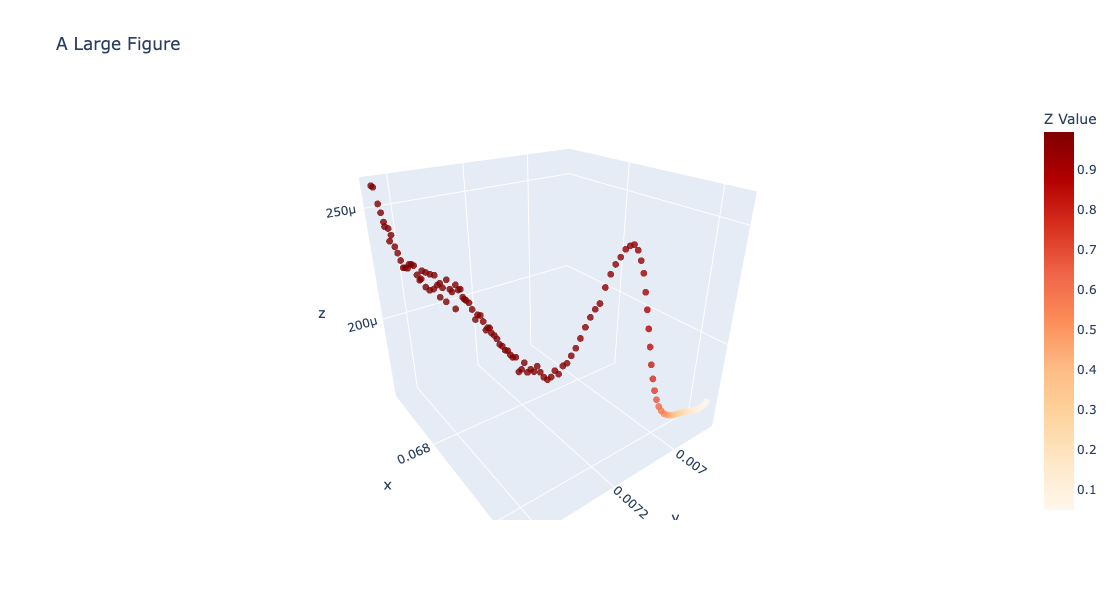

In [37]:
import plotly.express as px
import pandas as pd

# Load sample data (e.g., the Iris dataset)
# df = px.data.iris() 




import plotly.graph_objects as go

fig = go.Figure()

fig = go.Figure(data=[go.Scatter3d(
    x=result_df['x'], 
    y=result_df['y'], 
    z=result_df['z'], 
    mode='markers',
    marker=dict(
        size=4,
        color=result_df['c'],            # Set color to an array of values
        colorscale='OrRd', # Choose a colorscale (e.g., 'Viridis', 'Jet', 'Blues')
        opacity=0.8,
        colorbar=dict(title='Z Value') # Add a color bar
    )
)])

"""
for i in range(len(pathline)):
    fig.add_trace(go.Scatter3d(
        x=[result_df['x'].iloc[i]],
        y=[result_df['y'].iloc[i]],
        z=[result_df['z'].iloc[i]],
        mode='markers+text',
        
        
        textposition='top center',
        marker=dict(size=5,
                    color=result_df['c'].iloc[i],
                    colorscale='OrRd',
                   )
    ))
"""
fig.update_layout(
    width=800,
    height=600,
    title_text="A Large Figure"   # <- key line (1:1:1 scaling)
)



fig.show()

In [14]:
df_out[( df_out['x']>=0.06630859374999999)  &  ( df_out['x']<=0.06634277343749999) 
& ( df_out['y']>= 0.007724609375000001 )  &  ( df_out['y']<= 0.007758789062500001) 
& ( df_out['z']>= 8.544921875000001e-05)  &  ( df_out['z']<=0.00011962890625000001)] 



,x,y,z,temp,gridsize,gh2x,gh2y,gh2z,gh2mag,Y(H),Y(H2),Y(H2O),Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH)
10274,0.066343,0.007759,0.000103,667.573499,0.000068,-17.721016,15.046573,-9.224883,25.010642,0.000014,0.006604,0.041462,0.000083,0.000329,0.754217,0.000034,0.197087,0.000170
95756,0.066326,0.007742,0.000085,609.997616,0.000034,-17.982912,14.830507,-9.473670,25.161071,0.000007,0.006782,0.037211,0.000097,0.000353,0.754257,0.000016,0.201155,0.000123
95757,0.066326,0.007742,0.000120,718.208969,0.000034,-18.218437,14.586410,-9.484424,25.191846,0.000020,0.006451,0.046270,0.000070,0.000307,0.754130,0.000048,0.192488,0.000216


In [41]:
pwd


'/Users/potato/Downloads'

In [19]:
0.06632568359374999/0.000034

1950.7553998161761

In [57]:
0.06634277343749999/0.000034


1951.2580422794115

In [7]:

header_list

['Y(H)',
 'Y(H2)',
 'Y(H2O)',
 'Y(H2O2)',
 'Y(HO2)',
 'Y(N2)',
 'Y(O)',
 'Y(O2)',
 'Y(OH)']

In [8]:
ds.field_list

[('boxlib', 'FunctCall'),
 ('boxlib', 'HeatRelease'),
 ('boxlib', 'I_R(H)'),
 ('boxlib', 'I_R(H2)'),
 ('boxlib', 'I_R(H2O)'),
 ('boxlib', 'I_R(H2O2)'),
 ('boxlib', 'I_R(HO2)'),
 ('boxlib', 'I_R(N2)'),
 ('boxlib', 'I_R(O)'),
 ('boxlib', 'I_R(O2)'),
 ('boxlib', 'I_R(OH)'),
 ('boxlib', 'RhoRT'),
 ('boxlib', 'Y(H)'),
 ('boxlib', 'Y(H2)'),
 ('boxlib', 'Y(H2O)'),
 ('boxlib', 'Y(H2O2)'),
 ('boxlib', 'Y(HO2)'),
 ('boxlib', 'Y(N2)'),
 ('boxlib', 'Y(O)'),
 ('boxlib', 'Y(O2)'),
 ('boxlib', 'Y(OH)'),
 ('boxlib', 'avg_pressure'),
 ('boxlib', 'density'),
 ('boxlib', 'divu'),
 ('boxlib', 'gradpx'),
 ('boxlib', 'gradpy'),
 ('boxlib', 'gradpz'),
 ('boxlib', 'mag_vort'),
 ('boxlib', 'rhoh'),
 ('boxlib', 'temp'),
 ('boxlib', 'x_velocity'),
 ('boxlib', 'y_velocity'),
 ('boxlib', 'z_velocity')]